In [1]:
import os

In [2]:
# configurations
CONFIG = {
    'data_dir': 'pet_up_threshold_0.7',

    # A: Adenocarcinoma, B: Small Cell, G: Squamous Cell
    'classes': ['A', 'B', 'G'],
    'class_names': ['Adenocarcinoma', 'Small Cell', 'Squamous Cell'],
    'image_size': 128,

    # number of slices per sequence
    'seq_length': 8,
    'batch_size': 8,
    'num_epochs': 20,
    'learning_rate': 1e-4,
    'num_workers': 0,

    # early stopping settings
    'early_stopping_patience': 5,
    'early_stopping_min_delta': 0.0,

    'model_save_dir': 'pet_base',
}

# create model save directory
os.makedirs(CONFIG['model_save_dir'], exist_ok=True)

print('[ ] Configurations:\n')

for key, value in CONFIG.items():
    print(f'  {key}: {value}')

[ ] Configurations:

  data_dir: pet_up_threshold_0.7
  classes: ['A', 'B', 'G']
  class_names: ['Adenocarcinoma', 'Small Cell', 'Squamous Cell']
  image_size: 128
  seq_length: 8
  batch_size: 8
  num_epochs: 20
  learning_rate: 0.0001
  num_workers: 0
  early_stopping_patience: 5
  early_stopping_min_delta: 0.0
  model_save_dir: pet_base


In [3]:
import random
import numpy as np
import torch

# set random state
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# detect device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f'Device selected: {device}')

Device selected: cuda


In [4]:
from torch.utils.data import Dataset
from pathlib import Path

In [5]:
class PETSequenceDataset(Dataset):
    """
    Dataset for PET sequences.
    Each sequence is from a .npy file.
    Returns all slices for classification.
    """
    
    def __init__(self, data_dir, classes, seq_length=8, image_size=224):
        self.data_dir = Path(data_dir)
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.seq_length = seq_length
        self.image_size = image_size
        self.sequences = []
        
        # load all sequences
        for cls in classes:
            cls_dir = self.data_dir / cls
            if not cls_dir.exists():
                print(f'Warning: Directory {cls_dir} does not exist')
                continue
            
            for npy_file in sorted(cls_dir.glob("*.npy")):
                vol = np.load(npy_file)
                
                # split volume into sequences
                n_full = vol.shape[0] // self.seq_length
                for i in range(n_full):
                    start = i * self.seq_length
                    chunk = vol[start:start + self.seq_length]
                    
                    if chunk.shape[0] == self.seq_length:

                        # store original
                        self.sequences.append({
                            'sequence': chunk.astype(np.float32),
                            'label': self.class_to_idx[cls],
                            'class': cls,
                            'file': npy_file.name,
                            'is_augmented': False
                        })
        
        print(f'[ ] Loaded {len(self.sequences)} sequences\n')
        for cls in classes:
            count = sum(1 for s in self.sequences if s['class'] == cls)
            pct = (count/len(self.sequences)*100) if len(self.sequences) else 0
            print(f"  {cls}: {count} sequences ({pct:.1f}%)")
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        item = self.sequences[idx]
        sequence = item['sequence']  # Shape: (seq_length, H, W), range [0, 1]
        label = item['label']
        
        # convert each slice to PIL and then to RGB
        imgs = []
        for i in range(self.seq_length):
            slice_2d = sequence[i]
            slice_uint8 = (slice_2d * 255).astype(np.uint8)
            img_pil = Image.fromarray(slice_uint8).convert('RGB')
            imgs.append(img_pil)
        
        return imgs, label

In [6]:
import torchvision.transforms as transforms

In [7]:
# define transforms
transforms = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

In [9]:
# create dataset

# instantiate the full dataset
full_dataset = PETSequenceDataset(
    data_dir=CONFIG['data_dir'],
    classes=CONFIG['classes'],
    seq_length=CONFIG['seq_length'],
    image_size=CONFIG['image_size'],
)

class TransformedSubset(Dataset):
    """Wrapper to apply transforms to a subset of sequences, returns all slices as tensors."""
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    
    def __len__(self):
        return len(self.subset)
    
    def __getitem__(self, idx):
        global_idx = self.subset.indices[idx]
        imgs, label = self.subset.dataset[global_idx]
        
        # apply transform to each slice
        img_tensors = [self.transform(img) for img in imgs]  # list of tensors
        img_tensors = torch.stack(img_tensors, dim=0)  # (seq_length, 3, H, W)
        return img_tensors, label

# create stratified splits: 80% train, 10% val, 10% test
all_indices = list(range(len(full_dataset)))
all_labels = [full_dataset.sequences[i]['label'] for i in all_indices]

train_idx, temp_idx = train_test_split(
    all_indices, 
    test_size=(0.2),
    random_state=seed,
    stratify=all_labels
)

temp_labels = [all_labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=seed,
    stratify=temp_labels
)

# create subsets
train_subset = Subset(full_dataset, train_idx)
val_subset = Subset(full_dataset, val_idx)
test_subset = Subset(full_dataset, test_idx)

# wrap with transforms
train_dataset = TransformedSubset(train_subset, transforms)
val_dataset = TransformedSubset(val_subset, transforms)
test_dataset = TransformedSubset(test_subset, transforms)

# Dataset Characteristics table
print('\n[ ] Dataset Characteristics\n')
print(f'  {"Class":<22} {"Patients":>10} {"PET 2D":>12}')
print(f'  {"-"*50}')
for i, cls_name in enumerate(CONFIG['class_names']):
    cls_code = CONFIG['classes'][i]
    patients = len(set(s['file'] for s in full_dataset.sequences if s['class'] == cls_code))
    seq_count = sum(1 for s in full_dataset.sequences if s['class'] == cls_code)
    pet_2d = seq_count * CONFIG['seq_length']
    print(f'  {cls_name:<22} {patients:>10} {pet_2d:>12}')


[ ] Loaded 2089 sequences

  A: 1577 sequences (75.5%)
  B: 145 sequences (6.9%)
  G: 367 sequences (17.6%)

[ ] Dataset Characteristics

  Class                    Patients       PET 2D
  --------------------------------------------------
  Adenocarcinoma                 91        12616
  Small Cell                      9         1160
  Squamous Cell                  28         2936


In [10]:
# image slice count
def count_images_per_class(indices, dataset, class_names):

    # index rrepresents a sequence
    labels = [dataset.sequences[idx]['label'] for idx in indices]
    counts = {name: 0 for name in class_names}
    for i, name in enumerate(class_names):
        counts[name] = labels.count(i)
    return counts

print('[ ]2D images per class:\n')
splits = {
    'Train': train_idx,
    'Val': val_idx,
    'Test': test_idx
}
for split_name, split_indices in splits.items():
    counts = count_images_per_class(split_indices, full_dataset, CONFIG['class_names'])
    print(f'  {split_name}:')
    for cls_name in CONFIG['class_names']:
        print(f'    {cls_name}: {counts[cls_name] * 8}')

[ ]2D images per class:

  Train:
    Adenocarcinoma: 10088
    Small Cell: 928
    Squamous Cell: 2352
  Val:
    Adenocarcinoma: 1264
    Small Cell: 112
    Squamous Cell: 296
  Test:
    Adenocarcinoma: 1264
    Small Cell: 120
    Squamous Cell: 288


In [11]:
from torch.utils.data import DataLoader

In [12]:
# create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f'[ ] Data loaders created:\n')
print(f'  Train batches: {len(train_loader)}')
print(f'  Val batches: {len(val_loader)}')
print(f'  Test batches: {len(test_loader)}')

[ ] Data loaders created:

  Train batches: 209
  Val batches: 27
  Test batches: 27


In [13]:
import matplotlib.pyplot as plt
from PIL import Image

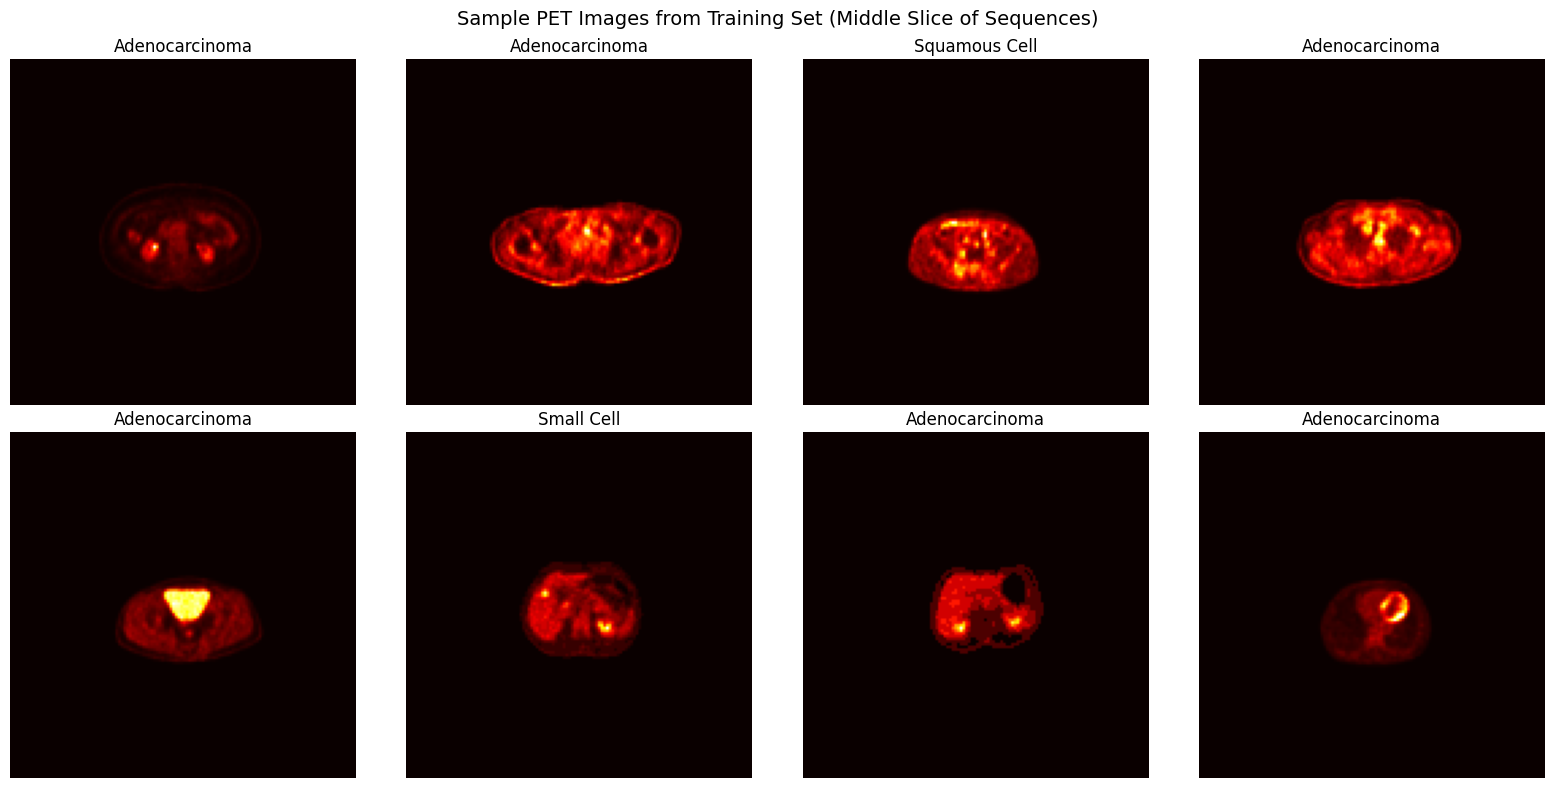

In [14]:
# visualize some samples from sequences
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# get a batch from train loader
sequences, labels = next(iter(train_loader))

# use ImageNet mean and std for un-normalization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# handle both (B, seq_len, 3, H, W) and (B, 3, H, W)
if sequences.ndim == 5:
    seq_len = sequences.size(1)
    middle_idx = seq_len // 2
elif sequences.ndim == 4:
    # if only (B, 3, H, W), treat as single slice
    middle_idx = 0
else:
    raise ValueError(f"Unexpected tensor shape: {sequences.shape}")

# display middle slice from first 8 sequences
for i in range(min(8, sequences.size(0))):
    if sequences.ndim == 5:
        img = sequences[i, middle_idx]  # (3, H, W)
    else:
        img = sequences[i].detach().cpu()  # (3, H, W)
    img = img * std + mean
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    
    # convert RGB to grayscale for colormap to work
    img_gray = np.mean(img, axis=2)
    
    axes[i].imshow(img_gray, cmap='hot')
    axes[i].set_title(f'{CONFIG["class_names"][labels[i].item()]}')
    axes[i].axis('off')

plt.suptitle('Sample PET Images from Training Set (Middle Slice of Sequences)', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
from torchvision import models
import torch.nn as nn

In [16]:
# ;oad pre-trained VGG16
model = models.vgg16(pretrained=True)

# modify the classifier for 3 classes
num_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_features, len(CONFIG['classes']))

# move model to device
model = model.to(device)

print(f'\nModel parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Model parameters: 134,272,835
Trainable parameters: 134,272,835


In [17]:
import torch.optim as optim

In [18]:
# define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print(f'Loss function: CrossEntropyLoss')
print(f'Optimizer: Adam (lr={CONFIG["learning_rate"]})')
print(f'Scheduler: ReduceLROnPlateau')

Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.0001)
Scheduler: ReduceLROnPlateau


In [19]:
from tqdm.auto import tqdm

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
# training function
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for seq_imgs, labels in tqdm(loader, desc='Training'):

        # seq_imgs: (batch, seq_length, 3, H, W), labels: (batch,)
        batch_size, seq_length, C, H, W = seq_imgs.shape
        seq_imgs = seq_imgs.view(-1, C, H, W).to(device)  # (batch*seq_length, 3, H, W)
        labels = labels.unsqueeze(1).repeat(1, seq_length).view(-1).to(device)
        
        optimizer.zero_grad()
        outputs = model(seq_imgs)  # (batch*seq_length, num_classes)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

# validation function
def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for seq_imgs, labels in tqdm(loader, desc='Validation'):
            batch_size, seq_length, C, H, W = seq_imgs.shape
            seq_imgs = seq_imgs.view(-1, C, H, W).to(device)
            labels = labels.unsqueeze(1).repeat(1, seq_length).view(-1).to(device)
            
            outputs = model(seq_imgs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

In [21]:
# training loop
train_losses = []
train_accs = []
val_losses = []
val_accs = []
best_val_acc = -float('inf')
best_epoch = -1

patience = CONFIG['early_stopping_patience']
min_delta = CONFIG['early_stopping_min_delta']
epochs_no_improve = 0

for epoch in range(CONFIG['num_epochs']):
    print(f'Epoch {epoch+1}/{CONFIG["num_epochs"]}')

    # train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # validate on val set
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # update learning rate
    scheduler.step(val_loss)

    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
    print(f'Val Loss:  {val_loss:.4f} | Val Acc:  {val_acc:.2f}%')

    # save best model
    if val_acc > best_val_acc + min_delta:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'train_loss': train_loss
        }, os.path.join(CONFIG['model_save_dir'], 'best.pt'))
        print(f'Best model saved with Val Acc: {val_acc:.2f}%')
    else:
        epochs_no_improve += 1
        print(f'No improvement for {epochs_no_improve}/{patience} epochs')

    print()

    if epochs_no_improve >= patience:
        print(f'Early stopping triggered at epoch {epoch+1}')
        break

print(f'Best Val Accuracy: {best_val_acc:.2f}% (Epoch {best_epoch})')

Epoch 1/20


Validation: 100%|██████████| 27/27 [00:02<00:00, 13.48it/s]


Train Loss: 0.7160 | Train Acc: 74.81%
Val Loss:  0.7100 | Val Acc:  68.18%
Best model saved with Val Acc: 68.18%

Epoch 2/20


Validation: 100%|██████████| 27/27 [00:02<00:00, 13.48it/s]


Train Loss: 0.6826 | Train Acc: 75.43%
Val Loss:  0.7126 | Val Acc:  75.60%
Best model saved with Val Acc: 75.60%

Epoch 3/20


...

Train Loss: 0.0852 | Train Acc: 96.90%
Val Loss:  0.5791 | Val Acc:  85.35%
No improvement for 1/5 epochs

Epoch 19/20


Validation: 100%|██████████| 27/27 [00:02<00:00, 13.48it/s]


Train Loss: 0.0773 | Train Acc: 97.58%
Val Loss:  0.5025 | Val Acc:  87.98%
Best model saved with Val Acc: 87.98%

Epoch 20/20


Validation: 100%|██████████| 27/27 [00:02<00:00, 13.49it/s]

Train Loss: 0.0552 | Train Acc: 97.88%
Val Loss:  0.5476 | Val Acc:  86.48%
No improvement for 1/5 epochs

Best Val Accuracy: 87.98% (Epoch 19)


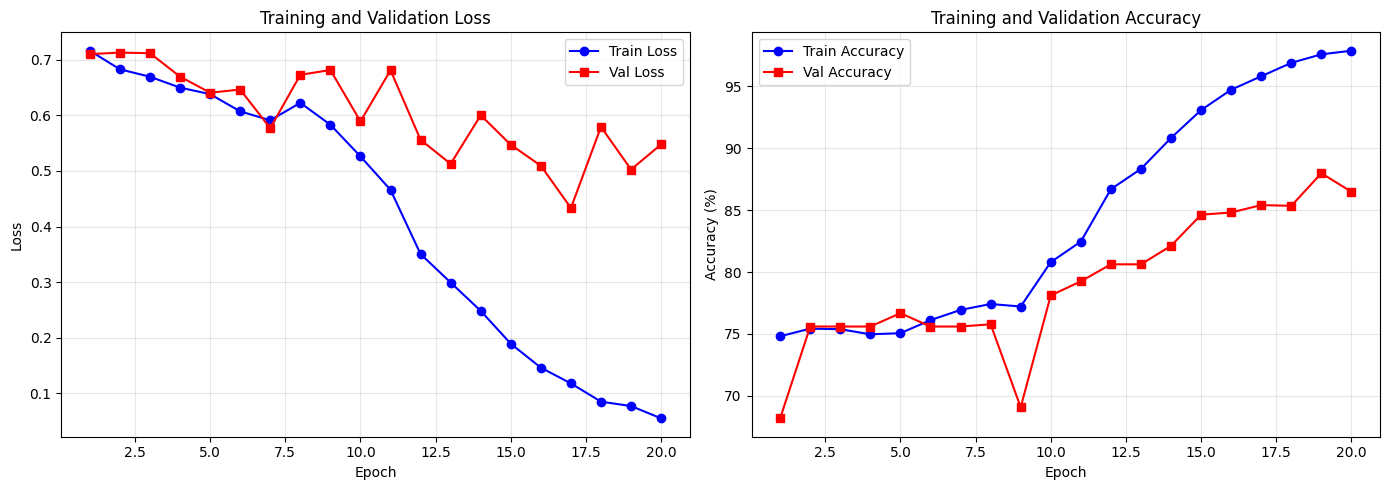

In [22]:
# plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = len(train_losses)
epoch_axis = range(1, epochs_ran + 1)

# loss plot
ax1.plot(epoch_axis, train_losses, 'b-', label='Train Loss', marker='o')
ax1.plot(epoch_axis, val_losses, 'r-', label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# accuracy plot
ax2.plot(epoch_axis, train_accs, 'b-', label='Train Accuracy', marker='o')
ax2.plot(epoch_axis, val_accs, 'r-', label='Val Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

In [24]:
# evaluate on validation set (treat all slices as independent images)
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for seq_imgs, labels in tqdm(val_loader, desc='Validation'):

        # seq_imgs: (batch, seq_length, 3, H, W), labels: (batch,)
        batch_size, seq_length, C, H, W = seq_imgs.shape
        seq_imgs = seq_imgs.view(-1, C, H, W).to(device)  # (batch*seq_length, 3, H, W)
        labels = labels.unsqueeze(1).repeat(1, seq_length).view(-1).to(device)
        outputs = model(seq_imgs)
        _, predicted = outputs.max(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# calculate metrics for single slices
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print('\n[ ] Overall Classification Metrics (Validation)\n')
print(f'  Accuracy:  {accuracy:.4f}')
print(f'  Precision: {precision:.4f}')
print(f'  Recall:    {recall:.4f}')
print(f'  F1-Score:  {f1:.4f}')

Validation: 100%|██████████| 27/27 [00:02<00:00, 13.49it/s]


[ ] Overall Classification Metrics (Validation)

  Accuracy:  0.8648
  Precision: 0.8552
  Recall:    0.8648
  F1-Score:  0.8553


In [25]:
# per-class metrics (validation)
print('\n[ ] Per-Class Classification Metrics\n')
for i, class_name in enumerate(CONFIG['class_names']):
    mask = y_true == i
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == i).sum() / mask.sum()

        # use binary arrays for precision/recall/f1 (one-vs-rest, no average param)
        class_prec = precision_score((y_true == i), (y_pred == i), zero_division=0)
        class_rec = recall_score((y_true == i), (y_pred == i), zero_division=0)
        class_f1 = f1_score((y_true == i), (y_pred == i), zero_division=0)
        print(f'{class_name}:')
        print(f'  Accuracy:  {class_acc:.4f}')
        print(f'  Precision: {class_prec:.4f}')
        print(f'  Recall:    {class_rec:.4f}')
        print(f'  F1-Score:  {class_f1:.4f}')


[ ] Per-Class Classification Metrics

Adenocarcinoma:
  Accuracy:  0.9589
  Precision: 0.8971
  Recall:    0.9589
  F1-Score:  0.9270
Small Cell:
  Accuracy:  0.3661
  Precision: 0.6949
  Recall:    0.3661
  F1-Score:  0.4795
Squamous Cell:
  Accuracy:  0.6520
  Precision: 0.7366
  Recall:    0.6520
  F1-Score:  0.6918


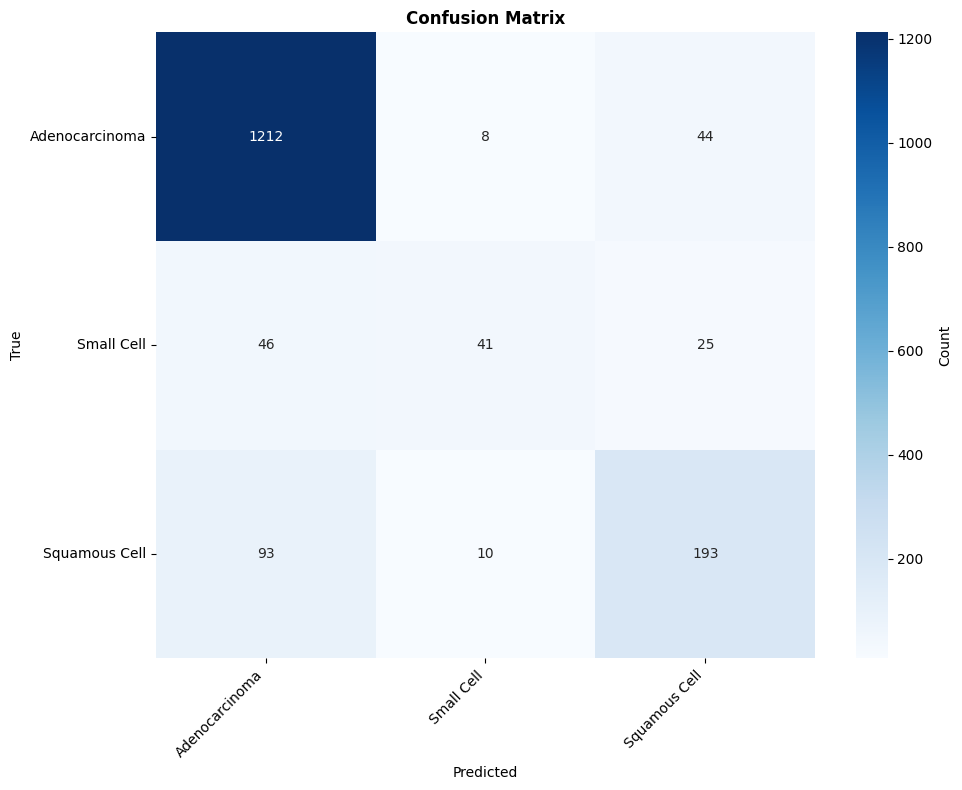

In [26]:
# confusion matrix (validation)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CONFIG['class_names'], yticklabels=CONFIG['class_names'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

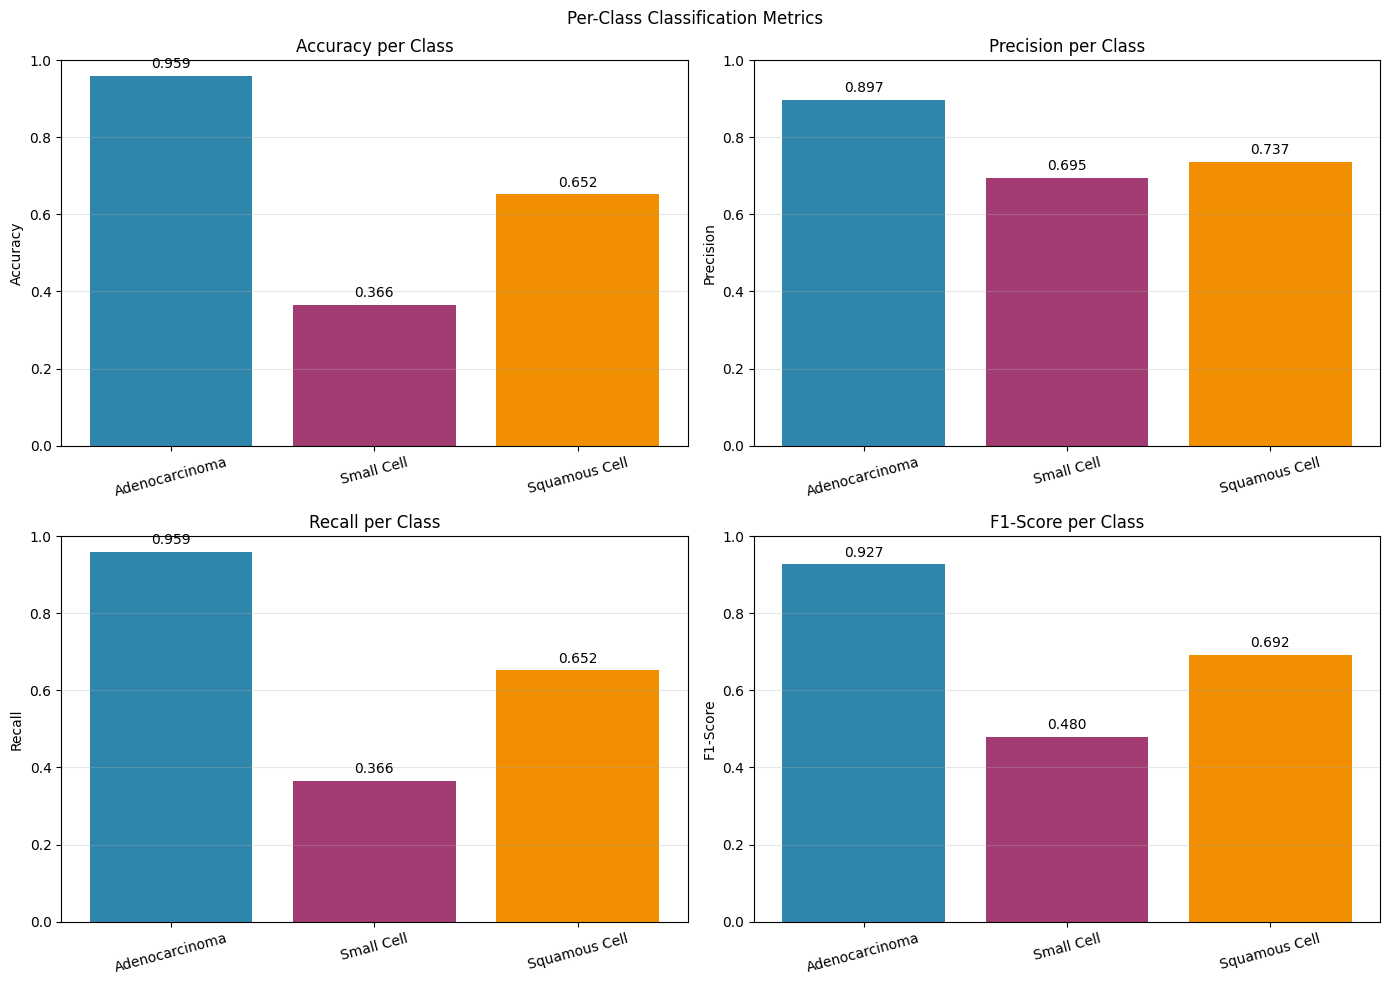

In [27]:
# per-class metrics visualization (validation)
class_accuracy_values = []
class_precision_values = []
class_recall_values = []
class_f1_values = []

for i, class_name in enumerate(CONFIG['class_names']):
    mask = y_true == i
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == i).sum() / mask.sum()
        class_prec = precision_score(y_true == i, y_pred == i, zero_division=0)
        class_rec = recall_score(y_true == i, y_pred == i, zero_division=0)
        class_f1 = f1_score(y_true == i, y_pred == i, zero_division=0)
    else:
        class_acc = 0.0
        class_prec = 0.0
        class_rec = 0.0
        class_f1 = 0.0
    
    class_accuracy_values.append(class_acc)
    class_precision_values.append(class_prec)
    class_recall_values.append(class_rec)
    class_f1_values.append(class_f1)

# color palette
colors = ['#2E86AB', '#A23B72', '#F18F01']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# accuracy
axes[0, 0].bar(CONFIG['class_names'], class_accuracy_values, color=colors)
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy per Class')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_accuracy_values):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[0, 0].tick_params(axis='x', rotation=15)

# precision
axes[0, 1].bar(CONFIG['class_names'], class_precision_values, color=colors)
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision per Class')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_precision_values):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[0, 1].tick_params(axis='x', rotation=15)

# recall
axes[1, 0].bar(CONFIG['class_names'], class_recall_values, color=colors)
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Recall per Class')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_recall_values):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[1, 0].tick_params(axis='x', rotation=15)

# F1-Score
axes[1, 1].bar(CONFIG['class_names'], class_f1_values, color=colors)
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].set_title('F1-Score per Class')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_f1_values):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.suptitle('Per-Class Classification Metrics')
plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

In [29]:
# get predicted probabilities for ROC and PR curves

model.eval()
y_true_prob = []
y_scores = []

with torch.no_grad():
    for seq_imgs, labels in tqdm(test_loader, desc='Computing probabilities'):
        batch_size, seq_length, C, H, W = seq_imgs.shape
        seq_imgs = seq_imgs.view(-1, C, H, W).to(device)  # (batch*seq_length, 3, H, W)
        labels = labels.unsqueeze(1).repeat(1, seq_length).view(-1).to(device)  # (batch*seq_length,)
        outputs = model(seq_imgs)
        probs = torch.softmax(outputs, dim=1)
        
        y_true_prob.extend(labels.cpu().numpy())
        y_scores.extend(probs.cpu().numpy())

y_true_prob = np.array(y_true_prob)
y_scores = np.array(y_scores)

# binarize the labels for multi-class ROC/PR curves
y_true_bin = label_binarize(y_true_prob, classes=[0, 1, 2])
n_classes = len(CONFIG['class_names'])

Computing probabilities: 100%|██████████| 27/27 [00:01<00:00, 13.50it/s]


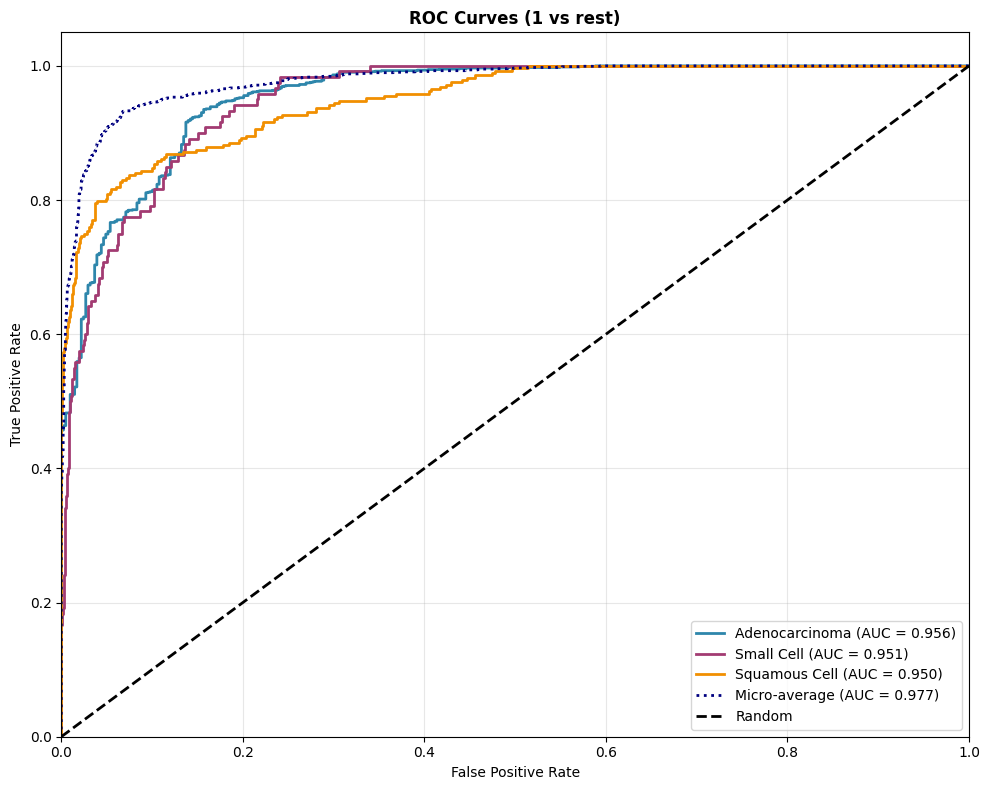


[ ] AUROC (Area Under ROC Curve)

Adenocarcinoma: 0.9556
Small Cell: 0.9515
Squamous Cell: 0.9502

Macro-average AUROC: 0.9524
Micro-average AUROC: 0.9774


In [30]:
# plot AUROC curves for each class
fig, ax = plt.subplots(figsize=(10, 8))

roc_auc = {}

for i, (class_name, color) in enumerate(zip(CONFIG['class_names'], colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[class_name] = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, 
            label=f'{class_name} (AUC = {roc_auc[class_name]:.3f})')

# Micro-average AUROC
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
ax.plot(fpr_micro, tpr_micro, color='navy', lw=2, linestyle=':', 
        label=f'Micro-average (AUC = {roc_auc_micro:.3f})')

# plot diagonal line
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (1 vs rest)',fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

# print AUC values
print('\n[ ] AUROC (Area Under ROC Curve)\n')
for class_name in CONFIG['class_names']:
    print(f'{class_name}: {roc_auc[class_name]:.4f}')
print(f'\nMacro-average AUROC: {np.mean(list(roc_auc.values())):.4f}')
print(f'Micro-average AUROC: {roc_auc_micro:.4f}')

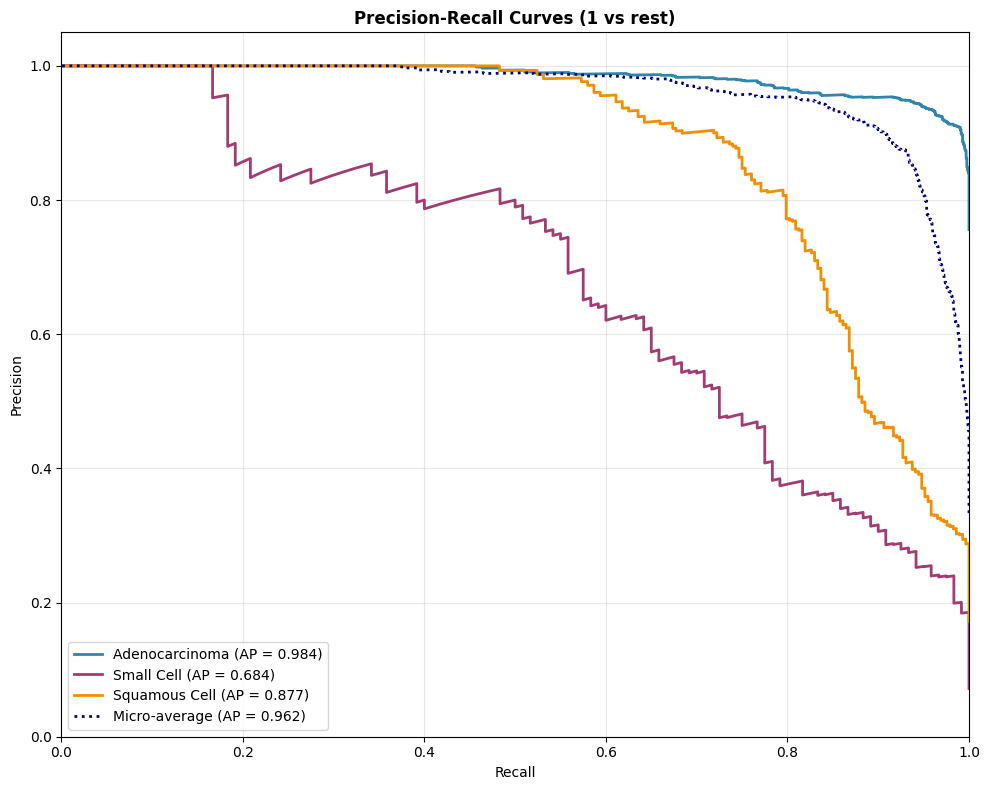


[ ] AUPRC (Area Under Precision-Recall Curve)

Adenocarcinoma: 0.9840
Small Cell: 0.6838
Squamous Cell: 0.8768

Macro-average AUPRC: 0.8482
Micro-average AUPRC: 0.9618


In [31]:

# plot AUPRC (Precision-Recall) curves for each class
fig, ax = plt.subplots(figsize=(10, 8))

pr_auc = {}

for i, (class_name, color) in enumerate(zip(CONFIG['class_names'], colors)):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
    pr_auc[class_name] = average_precision_score(y_true_bin[:, i], y_scores[:, i])
    ax.plot(recall, precision, color=color, lw=2, 
            label=f'{class_name} (AP = {pr_auc[class_name]:.3f})')

# Micro-average AUPRC
pr_auc_micro = average_precision_score(y_true_bin, y_scores, average='micro')
precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_scores.ravel())
ax.plot(recall_micro, precision_micro, color='navy', lw=2, linestyle=':',
        label=f'Micro-average (AP = {pr_auc_micro:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (1 vs rest)', fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

# print AP values
print('\n[ ] AUPRC (Area Under Precision-Recall Curve)\n')
for class_name in CONFIG['class_names']:
    print(f'{class_name}: {pr_auc[class_name]:.4f}')
print(f'\nMacro-average AUPRC: {np.mean(list(pr_auc.values())):.4f}')
print(f'Micro-average AUPRC: {pr_auc_micro:.4f}')

In [32]:
# find optimal thresholds for each class to maximize F1 score on validation set

# get model predictions probabilities for validation set
model.eval()
y_val_true = []
y_val_scores = []

with torch.no_grad():
    for seq_imgs, labels in tqdm(val_loader, desc='Validation Threshold Search'):
        batch_size, seq_length, C, H, W = seq_imgs.shape
        seq_imgs = seq_imgs.view(-1, C, H, W).to(device)  # (batch*seq_length, 3, H, W)
        labels = labels.unsqueeze(1).repeat(1, seq_length).view(-1).to(device)  # (batch*seq_length,)
        outputs = model(seq_imgs)
        probs = torch.softmax(outputs, dim=1)
        y_val_true.extend(labels.cpu().numpy())
        y_val_scores.extend(probs.cpu().numpy())

y_val_true = np.array(y_val_true)
y_val_scores = np.array(y_val_scores)

# find best threshold for each class
best_thresholds = []
best_f1s = []
class_names = CONFIG['class_names']
for i, class_name in enumerate(class_names):
    precision, recall, thresholds = precision_recall_curve((y_val_true == i).astype(int), y_val_scores[:, i])
    f1s = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.nanargmax(f1s)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_f1 = f1s[best_idx]
    best_thresholds.append(best_threshold)
    best_f1s.append(best_f1)
    print(f"Class {class_name}: Best threshold = {best_threshold:.3f}, F1 = {best_f1:.3f}")

# apply optimal thresholds to validation predictions
y_val_pred = []
for row in y_val_scores:
    pred = [row[i] > best_thresholds[i] for i in range(len(class_names))]
    if sum(pred) == 1:
        y_val_pred.append(np.argmax(pred))
    else:
         # fallback to max prob
        y_val_pred.append(np.argmax(row))

y_val_pred = np.array(y_val_pred)

Validation Threshold Search: 100%|██████████| 27/27 [00:02<00:00, 13.44it/s]

Class Adenocarcinoma: Best threshold = 0.677, F1 = 0.930
Class Small Cell: Best threshold = 0.254, F1 = 0.663
Class Squamous Cell: Best threshold = 0.035, F1 = 0.720


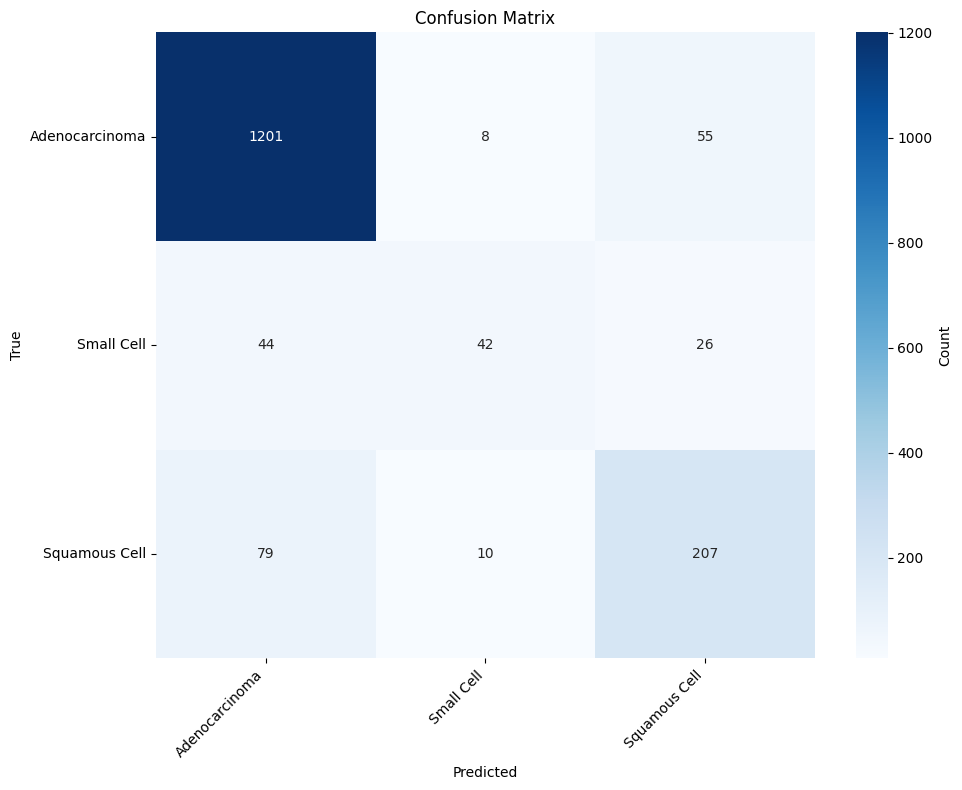

In [33]:
# confusion matrix for validation set with optimal thresholds
cm_val = confusion_matrix(y_val_true, y_val_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
           xticklabels=class_names, yticklabels=class_names,
           cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
import re

In [35]:
output_dir = Path(CONFIG['model_save_dir']) / 'test_imgs'
output_dir.mkdir(parents=True, exist_ok=True)

for seq_idx in test_idx:
    seq_info = full_dataset.sequences[seq_idx]
    sequence = seq_info['sequence']  # (seq_length, H, W)
    file_base = Path(seq_info['file']).stem

    # remove 'Lung-PET-CT-Dx-' prefix (case-insensitive)
    file_base_clean = re.sub(r'(?i)^lung-pet-ct-dx-?', '', file_base)
    
    for slice_idx in range(sequence.shape[0]):
        slice_2d = sequence[slice_idx]
        slice_uint8 = (slice_2d * 255).astype('uint8')
        img_pil = Image.fromarray(slice_uint8).convert('RGB')
        
        img_name = f"{file_base_clean}_seq{seq_idx}_slice{slice_idx}.png"
        img_path = output_dir / img_name
        img_pil.save(img_path)

print(f"Saved test data split.")

Saved test data split.
